In [39]:
from langgraph.graph import StateGraph, START,END 
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field

In [40]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [41]:
class sentimentstruct(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

In [42]:
sentiment_llm = llm.with_structured_output(sentimentstruct)

In [43]:
class diagnosis_struct(BaseModel):
    issue_type: Literal["billing", "tech", "delivery", "other"] = Field(description="What is the issue according to the negative review")
    tone: Literal["angry", "frustrated", "calm", "neutral"] = Field(description="What is the tone of the reviewer")
    urgency: Literal["low", "medium", "high"] = Field(description="What urgency should the issue be resolved with")

In [44]:
diagnosis_llm = llm.with_structured_output(diagnosis_struct)

In [45]:
class LLMstate(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    response: str

    #Run diagnosis Variables
    issue_type: Literal["billing", "tech", "delivery", "other"]
    tone: Literal["angry", "frustrated", "calm", "neutral"]
    urgency: Literal["low", "medium", "high"]

In [46]:
def find_sentiment(state: LLMstate) -> LLMstate:
    review = state["review"]

    result = sentiment_llm.invoke(review)
    state["sentiment"] = result.sentiment
    
    return state

In [47]:
def conditional(state: LLMstate) -> Literal["diagnosis","positive_response"]:
    sentiment = state["sentiment"]
    if sentiment == "negative":
        return "diagnosis"
    else:
        return "positive_response"


In [48]:
def diagnosis(state: LLMstate) -> LLMstate:
    review = state["review"]
    result = diagnosis_llm.invoke(review)

    state["issue_type"] = result.issue_type
    state["tone"] = result.tone
    state["urgency"] = result.urgency

    return state

In [49]:
def negative_response(state: LLMstate) -> LLMstate:
    result = llm.invoke(f"Make an appropriate response to the review: {state["review"]}, with the characterstics: issue type: {state['issue_type']}, tone of user: {state['tone']} and how urgent it is: {state['urgency']}. respond accordingly")
    state["response"] = result.content
    return state 

In [50]:
def positive_response(state: LLMstate) -> LLMstate:
    result = llm.invoke(f"Write a upbeat response to the positive review: {state['review']}")
    state["response"] = result.content
    return state 

In [51]:
graph = StateGraph(LLMstate)

In [52]:
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("diagnosis",diagnosis)
graph.add_node("negative_response",negative_response)
graph.add_node("positive_response",positive_response)

In [53]:
graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",conditional)
graph.add_edge("diagnosis","negative_response")
graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)

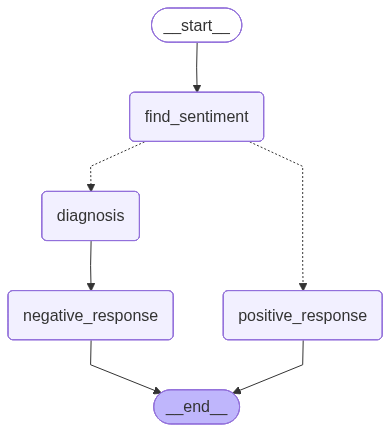

In [54]:
workflow = graph.compile()
workflow

In [57]:
initial_state = {"review":"This phone has a terrible keyboard. i cant work with this at all. i am so frustrated. fix this ASAP"}
final_state = workflow.invoke(initial_state)

In [60]:
final_state

{'review': 'This phone has a terrible keyboard. i cant work with this at all. i am so frustrated. fix this ASAP',
 'sentiment': 'negative',
 'response': "Dear [Customer Name, if available, otherwise 'Dear Valued Customer'],\n\nWe are so sorry to hear you're experiencing such significant frustration with your phone's keyboard. We completely understand how incredibly frustrating it must be when a core function like the keyboard isn't working as it should, making your device unusable. Please accept our sincere apologies for this inconvenience.\n\nYou're right, this sounds like a critical tech issue that needs immediate attention, and we want to resolve this for you as quickly as possible.\n\nTo help us diagnose and fix this, please reach out to our dedicated technical support team immediately. They are equipped to troubleshoot keyboard issues, explore potential software fixes, or arrange for a replacement if necessary.\n\nYou can contact them directly via:\n\n*   **Phone:** [Your Support 